<a href="https://colab.research.google.com/github/kaydominium/csui-archive/blob/main/CSGE603130/TP1_A3_K_A2C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TUGAS KELOMPOK 1 - Life Expectancy**

Kelompok **K-A2AC**
1. Arya Putra Parikesit (2406406300)
2. Cathlin Abigail (2406418774)
3. Khawarizmi Aydin (2406396584)
4. Msy Aulya Salsabila Putri (2406353364)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns', None)

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# clean the spacing
df_train.columns = df_train.columns.str.strip()
df_test.columns = df_test.columns.str.strip()

df_train.drop_duplicates()

df_train['Status'] = df_train['Status'].map({'Developing': 1, 'Developed': 0})

display(df_train.head())
display(df_train.info())

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Measles,BMI,under-five deaths,Total expenditure,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Hepatitis B,Polio,Diphtheria,Population,HIV/AIDS
0,1967,0,75.958705,30.409030,7,16.891705,100.000000,77790,7.022069,10,20.000000,79835.055962,0.633306,0.530616,0.747018,12.774990,0.0,76.0,92.0,64121.0,0.100000
1,1990,1,42.915277,101.499444,18,8.230195,0.000000,2106,5.000000,28,3.613611,10.000000,11.396052,11.049630,0.300171,9.982904,100.0,53.0,35.0,2364183.0,4.976989
2,1974,1,49.322096,209.702245,81,0.010000,0.000000,0,30.193667,108,6.405683,1766.947595,4.906007,4.736414,0.440699,7.317002,0.0,100.0,100.0,821554.0,0.100000
3,1970,1,30.000000,452.548059,168,5.347899,0.000000,29763,10.879758,298,0.000000,1766.947595,11.346782,11.946921,0.677000,12.300000,0.0,83.0,63.0,738541.0,0.100000
4,2010,1,61.800000,261.000000,162,1.340000,67.733744,4235,15.600000,243,6.860000,341.399920,11.000000,1.700000,0.401000,8.100000,62.0,69.0,61.0,877267.0,1.700000


<class 'pandas.DataFrame'>
RangeIndex: 10070 entries, 0 to 10069
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             10070 non-null  int64  
 1   Status                           10070 non-null  int64  
 2   Life expectancy                  10062 non-null  float64
 3   Adult Mortality                  10062 non-null  float64
 4   infant deaths                    10070 non-null  int64  
 5   Alcohol                          9920 non-null   float64
 6   percentage expenditure           10070 non-null  float64
 7   Measles                          10070 non-null  int64  
 8   BMI                              10047 non-null  float64
 9   under-five deaths                10070 non-null  int64  
 10  Total expenditure                9894 non-null   float64
 11  GDP                              9707 non-null   float64
 12  thinness  1-19 years         

None

## Data Preprocessing

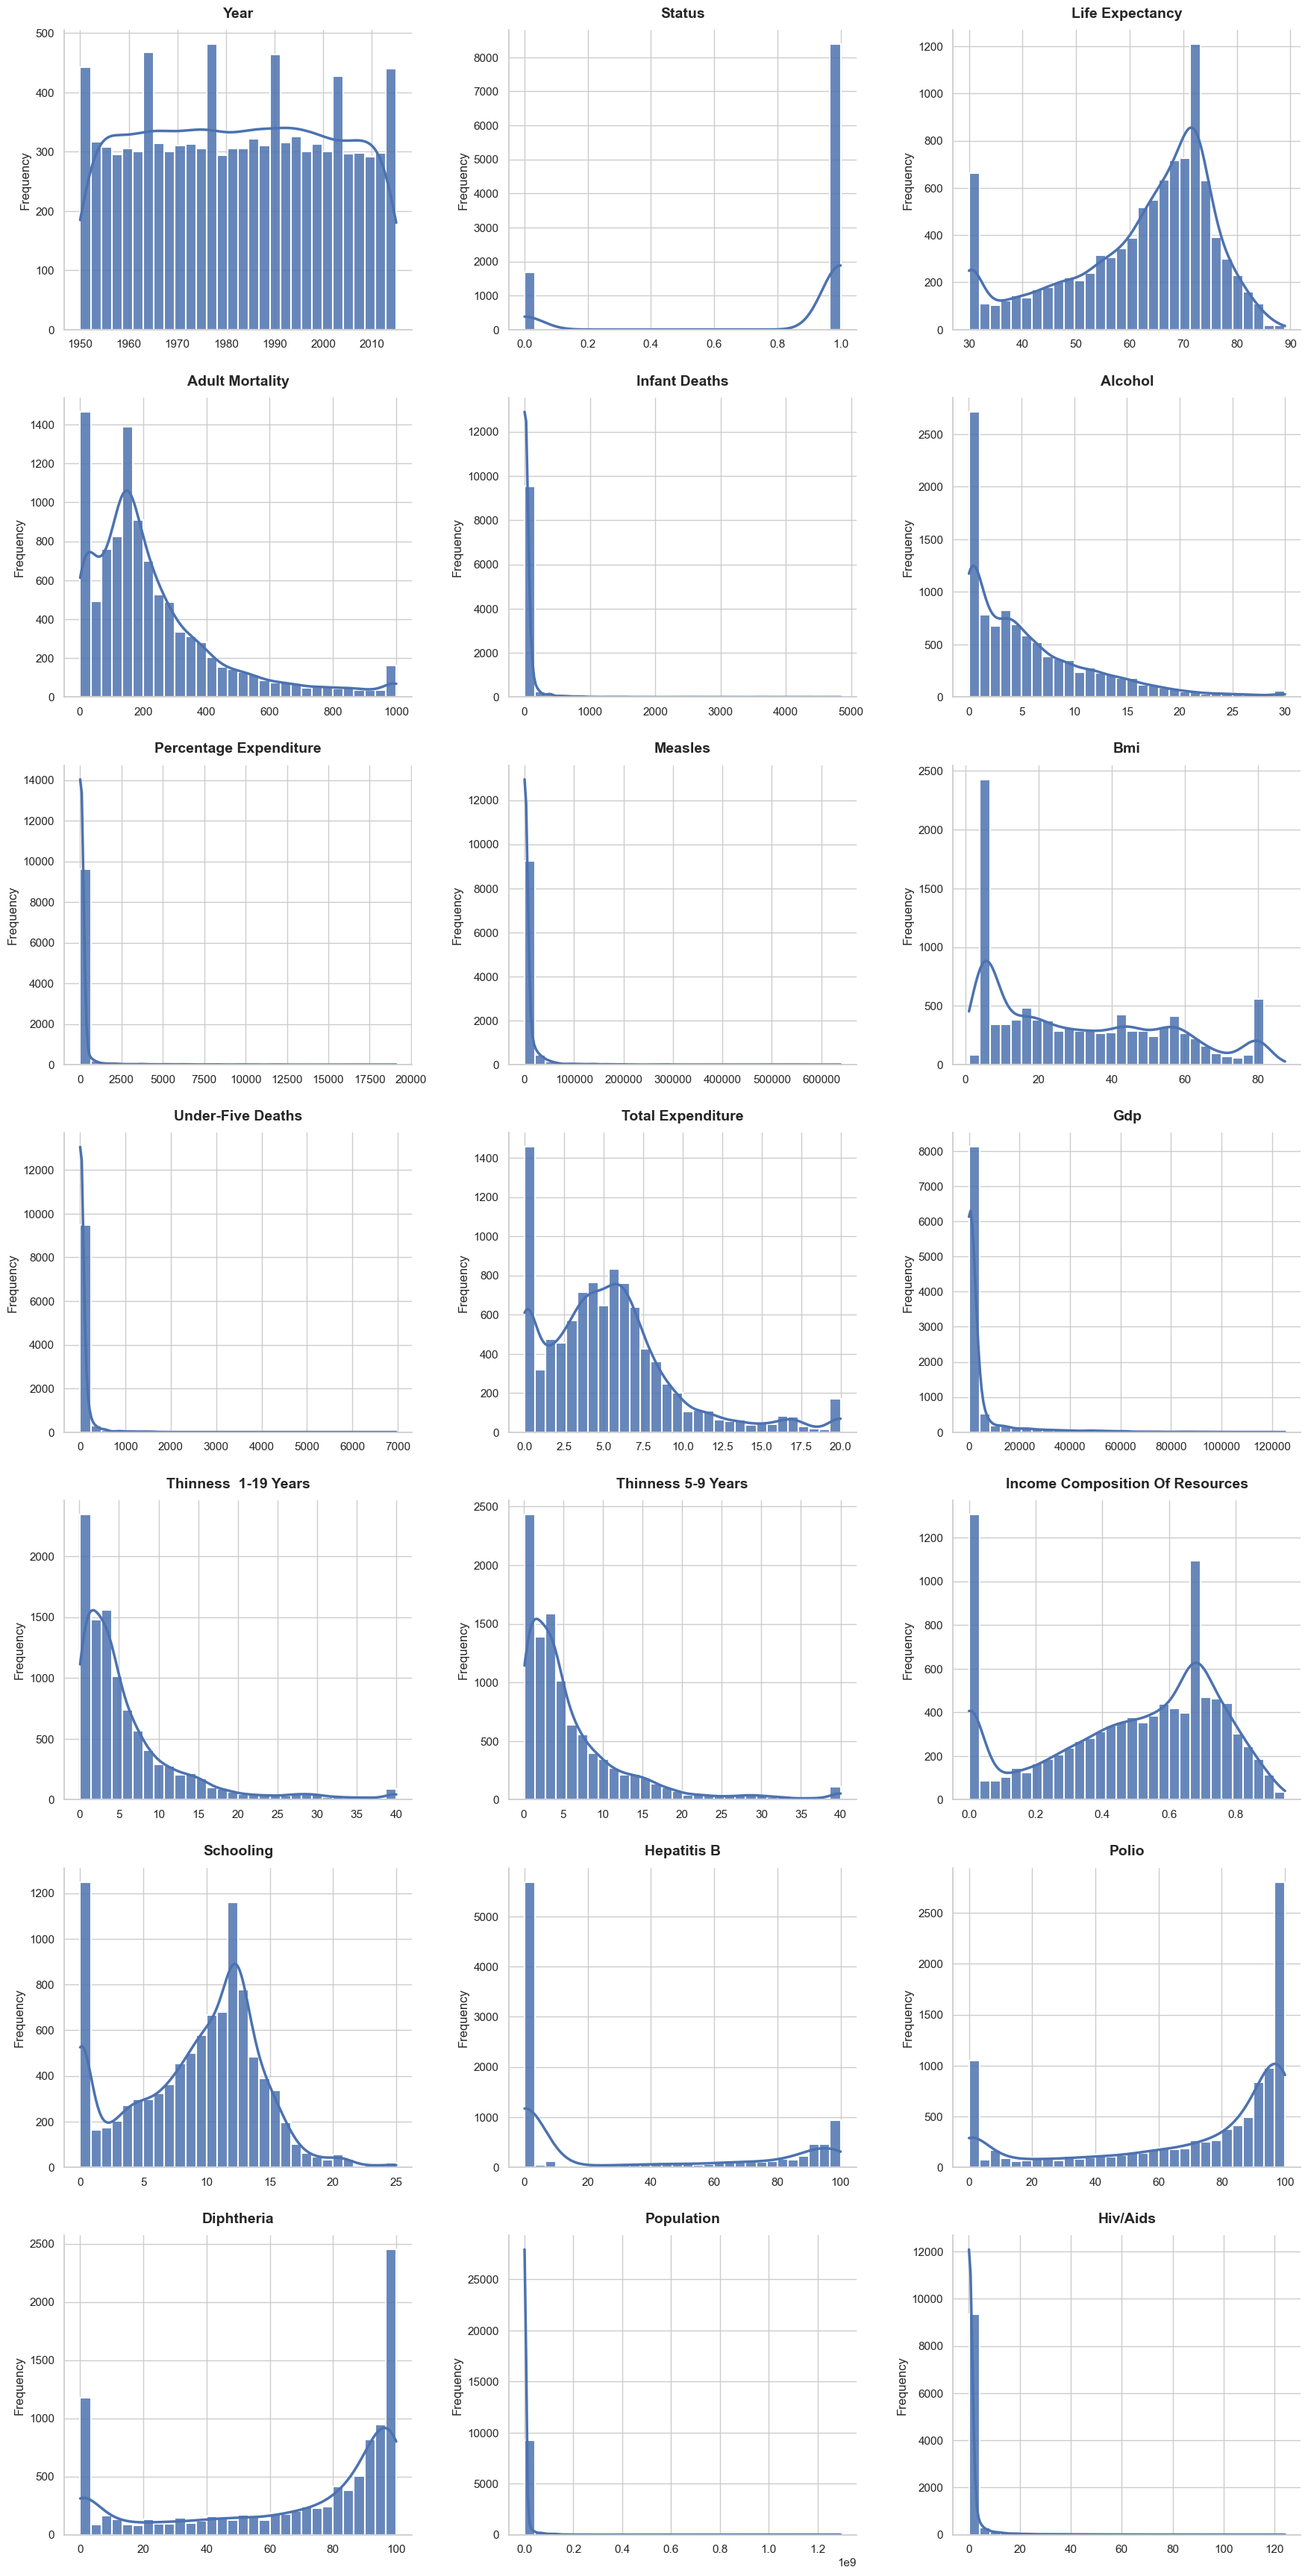

In [ ]:
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

num_cols = df_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

n_num = len(num_cols)
ncols = 3
nrows = (n_num + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        x=df_train[col],
        kde=True,
        bins=30,
        color='#4C72B0',
        edgecolor='white',
        linewidth=1.5,
        alpha=0.85,
        ax=axes[i],
        line_kws={'linewidth': 2.5}
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=14, fontweight='bold', pad=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency', fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=2.0)
plt.show()

In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

summary_data = []

def add_summary(col):
    desc = df_train[col].describe()
    summary_data.append({
        'Feature': col,
        'Count': int(desc.get('count', 0)),
        'Null Values': df_train[col].isna().sum(),
        'Mean': desc.get('mean', 0),
        'Std': desc.get('std', 0),
        'Min': desc.get('min', 0),
        '25%': desc.get('25%', 0),
        '50%': desc.get('50%', 0),
        '75%': desc.get('75%', 0),
        'Max': desc.get('max', None),
    })

col_per_1000 = ['Adult Mortality', 'infant deaths', 'under-five deaths', 'HIV/AIDS', 'Measles']
for col in col_per_1000:
    df_train.loc[df_train[col] > 1000, col] = np.nan
    df_train.loc[df_train[col] < 0, col] = np.nan
    add_summary(col)

col_per_100 = ['Hepatitis B', 'Polio', 'Diphtheria', 'thinness 5-9 years', 'thinness  1-19 years', 'percentage expenditure', 'Total expenditure']
for col in col_per_100:
    df_train.loc[df_train[col] > 100, col] = np.nan
    df_train.loc[df_train[col] < 0, col] = np.nan
    add_summary(col)

for col in col_per_100:
    df_train.loc[df_train[col] > 100, col] = np.nan
    df_train.loc[df_train[col] < 0, col] = np.nan

add_summary('BMI')
add_summary('Schooling')
add_summary('Income composition of resources')
add_summary('Alcohol')
add_summary('GDP')
add_summary('Population')

summary_table = pd.DataFrame(summary_data)
display(summary_table)

pd.reset_option('display.float_format')

,Feature,Count,Null Values,Mean,Std,Min,25%,50%,75%,Max
0,Adult Mortality,10062,8,232.45,213.87,1.00,93.08,171.28,300.02,"1,000.00"
1,infant deaths,9998,72,33.82,90.57,0.00,0.00,4.00,28.00,"1,000.00"
2,under-five deaths,9939,131,44.05,103.59,0.00,0.00,5.00,39.00,970.00
3,HIV/AIDS,10070,0,1.71,7.54,0.10,0.10,0.10,0.27,124.08
4,Measles,6957,3113,86.55,192.68,0.00,0.00,0.00,50.00,999.00
5,Hepatitis B,9614,456,31.15,41.10,0.00,0.00,0.00,80.00,100.00
6,Polio,10057,13,70.76,34.11,0.00,53.00,87.00,97.00,100.00
7,Diphtheria,10057,13,67.34,35.32,0.00,42.00,84.00,96.00,100.00
8,thinness 5-9 years,10047,23,6.13,7.17,0.10,1.50,3.73,7.81,40.00
9,thinness 1-19 years,10047,23,6.13,7.17,0.10,1.60,3.78,7.66,40.00


### EDA

In [ ]:
df_train.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Measles,BMI,under-five deaths,Total expenditure,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Hepatitis B,Polio,Diphtheria,Population,HIV/AIDS
0,1967,0,75.958705,30.409030,7.0,16.891705,100.000000,NaN,7.022069,10.0,20.000000,79835.055962,0.633306,0.530616,0.747018,12.774990,0.0,76.0,92.0,64121.0,0.100000
1,1990,1,42.915277,101.499444,18.0,8.230195,0.000000,NaN,5.000000,28.0,3.613611,10.000000,11.396052,11.049630,0.300171,9.982904,100.0,53.0,35.0,2364183.0,4.976989
2,1974,1,49.322096,209.702245,81.0,0.010000,0.000000,0.0,30.193667,108.0,6.405683,1766.947595,4.906007,4.736414,0.440699,7.317002,0.0,100.0,100.0,821554.0,0.100000
3,1970,1,30.000000,452.548059,168.0,5.347899,0.000000,NaN,10.879758,298.0,0.000000,1766.947595,11.346782,11.946921,0.677000,12.300000,0.0,83.0,63.0,738541.0,0.100000
4,2010,1,61.800000,261.000000,162.0,1.340000,67.733744,NaN,15.600000,243.0,6.860000,341.399920,11.000000,1.700000,0.401000,8.100000,62.0,69.0,61.0,877267.0,1.700000


#### Arya

Apakah tingkat pendidikan (`Schooling`) dan status perkembangan negara (`Status`) mempengaruhi harapan hidup (`Life expectancy`)?

In [ ]:
my_columns = ['Schooling', 'Status', 'Life expectancy']
print("Jumlah Data Kosong (NaN) di bagian ini:")
print(df_train[my_columns].isnull().sum())

my_df = df_train[my_columns].copy()

for column in ['Schooling', 'Life expectancy']:
  print("Skewness of", column, ":", my_df[column].skew())
  print("Kurtosis of", column, ":", my_df[column].kurt())

# schooling: skewness/kurtosis low (-0.17 and 0.08 respectively), can use mean
my_df['Schooling'] = my_df['Schooling'].fillna(my_df['Schooling'].mean())

# LE: skewness -0.77 and kurtosis -0.05. not an issue (see Gravetter and Wallnau, 2012)
my_df['Life expectancy'] = my_df['Life expectancy'].fillna(my_df['Life expectancy'].mean())

Jumlah Data Kosong (NaN) di bagian ini:
Schooling          137
Status               0
Life expectancy      8
dtype: int64
Skewness of Schooling : -0.27327460986406443
Kurtosis of Schooling : -0.5284118563031464
Skewness of Life expectancy : -0.8148250370366561
Kurtosis of Life expectancy : -0.23124775534238395


Correlation between Schooling and Life Expectancy: 0.5689778268276388
Correlation between Status and Life Expectancy: -0.32966683657229096


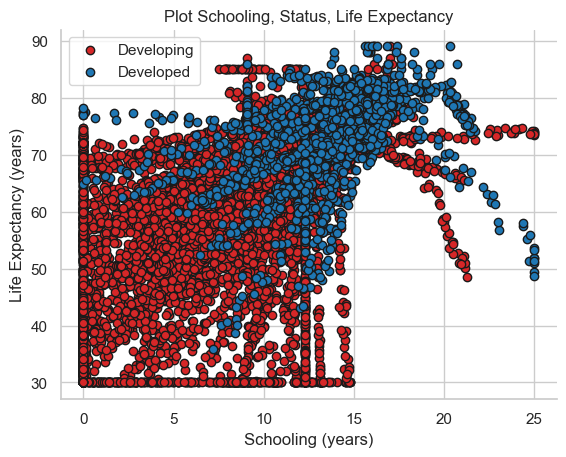

In [ ]:
# Draw a graph and calculate the correlations
developed_data = my_df.loc[my_df['Status'] == 0]
developing_data = my_df.loc[my_df['Status'] == 1]

fig, ax = plt.subplots()
ax.scatter(developing_data['Schooling'], developing_data['Life expectancy'], c='tab:red', edgecolors='k', label='Developing')
ax.scatter(developed_data['Schooling'], developed_data['Life expectancy'], c='tab:blue', edgecolors='k', label='Developed')
ax.set_xlabel("Schooling (years)")
ax.set_ylabel("Life Expectancy (years)")
ax.set_title("Plot Schooling, Status, Life Expectancy")
ax.legend()

school_corr = my_df['Schooling'].corr(my_df['Life expectancy'])
status_corr = my_df['Status'].corr(my_df['Life expectancy'])
print("Correlation between Schooling and Life Expectancy:", school_corr)
print("Correlation between Status and Life Expectancy:", status_corr)

##### Interpretasi
- Korelasi antara Schooling (rata-rata lama sekolah di negara tersebut) dengan Life Expectancy (harapan hidup) adalah 0,57. Ini menunjukkan korelasi positif tingkat sedang: ada kecenderungan harapan hidup di suatu negara naik seiring dengan kualitas dan aksesibilitas pendidikan. Kita dapat melihat hubungan ini pada grafik. Posisi titik di sumbu-y (Life expectancy) naik bersama dengan sumbu-x (Schooling) sampai sekitar x=18. Setelah x=18, ada tren harapan hidup turun baik untuk negara berkembang maupun negara maju.
- Korelasi antara Status (status negara sebagai berkembang atau maju) dengan Life Expectancy adalah -0,33. Ini menunjukkan korelasi negatif tingkat kecil-sedang: ada sedikit kecenderungan nilai LE turun jika Status (yang di-*encoding*) naik. Perlu diingat bahwa kita meng-*encoding* negara berkembang dengan angka 1, dan negara maju dengan angka 0. Ini artinya negara berkembang umumnya memiliki harapan hidup lebih pendek daripada negara maju. Hal ini juga tercerminkan pada grafik: semakin tinggi LE maka semakin cenderung titik di LE tersebut adalah negara maju. Ini pun sesuai dengan dunia nyata. Banyak negara maju memiliki taraf hidup yang mendukung *life expectancy* tinggi, misalnya melalui fasilitas medis, sanitasi, gizi, keamanan, dan sebagainya.

Oleh karena itu, tampak bahwa fitur Schooling dan Status memiliki korelasi terhadap Life Expectancy. Namun, diperlukan penelitian lebih lanjut untuk membuktikan apakah kedua fitur tersebut memengaruhi (memiliki hubungan kausasi terhadap) Life Expectancy.

#### Cathlin

Apakah `GDP` dan pengeluaran kesehatan (`Total expenditure`) berkorelasi dengan `Life expectancy`?

In [ ]:
# Pre Processing (untuk No. 2)

# cek skewness and kurtosis
kolom_no2 = ['GDP', 'Total expenditure', 'Life expectancy']
for col in kolom_no2:
    print(f"Skewness of {col}: {df_train[col].skew():.2f}")
    print(f"Kurtosis of {col}: {df_train[col].kurt():.2f}")

# imputasi with median -> karena skewness dan kurtosis high (>1)
df2 = df_train.copy()
df2['GDP'] = df2['GDP'].fillna(df2['GDP'].median())
df2['Total expenditure'] = df2['Total expenditure'].fillna(df2['Total expenditure'].median())
df2['Life expectancy'] = df2['Life expectancy'].fillna(df2['Life expectancy'].median())

Skewness of GDP: 4.72
Kurtosis of GDP: 26.72
Skewness of Total expenditure: 1.23
Kurtosis of Total expenditure: 1.95
Skewness of Life expectancy: -0.81
Kurtosis of Life expectancy: -0.23


--- Nilai Korelasi Pearson ---
                        GDP  Total expenditure  Life expectancy
GDP                1.000000           0.107259         0.289329
Total expenditure  0.107259           1.000000         0.106823
Life expectancy    0.289329           0.106823         1.000000
------------------------------


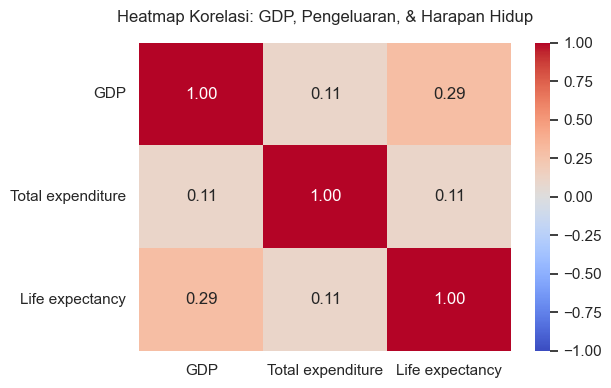


Scatter Plot


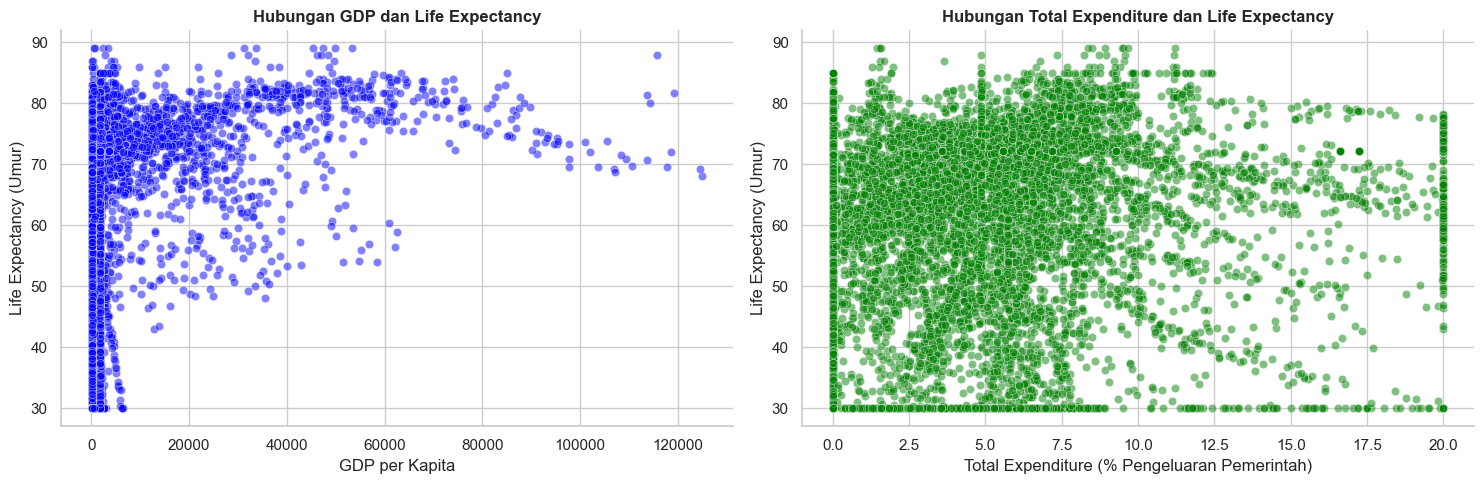

In [ ]:
# EDA; korelasi dan visualisasi

# hitung angka korelasi dulu
korelasi = df2[kolom_no2].corr()
print("--- Nilai Korelasi Pearson ---")
print(korelasi)
print("-" * 30)

# visualisasi heatmap
plt.figure(figsize=(6,4))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi: GDP, Pengeluaran, & Harapan Hidup', pad=15)
plt.show()

# visualisasi scatter plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# first plot: GDP vs. Life Expectancy
sns.scatterplot(data=df2, x='GDP', y='Life expectancy', ax=axes[0], alpha=0.5, color='blue')
axes[0].set_title('Hubungan GDP dan Life Expectancy', fontweight='bold')
axes[0].set_xlabel('GDP per Kapita')
axes[0].set_ylabel('Life Expectancy (Umur)')

print()

# second plot: Total Expenditure (pengeluaran kesehatan) vs. Life Expectancy
print("Scatter Plot")
sns.scatterplot(data=df2, x='Total expenditure', y='Life expectancy', ax=axes[1], alpha=0.5, color='green')
axes[1].set_title('Hubungan Total Expenditure dan Life Expectancy', fontweight='bold')
axes[1].set_xlabel('Total Expenditure (% Pengeluaran Pemerintah)')
axes[1].set_ylabel('Life Expectancy (Umur)')

plt.tight_layout()
plt.show()

##### Interpretasi
1. Analisis GDP vs Harapan Hidup (Life Expectancy)
    *   Dilihat dari Heatmap, angka korelasi Pearson sebesar 0.29
    menunjukkan adanya korelasi positif yang lemah hingga menengah (low-moderate). Tanda positif berarti pergerakannya searah, saat GDP naik, harapan hidup cenderung ikut naik.
    *   Dilihat dari Scatter Plot (Grafik biru), titik biru terlihat perlahan naik ke atas dari kiri ke kanan menuju angka harapan hidup 70-80 tahun (terutama di sekitar GDP 0-80.000).

    *   Maka dapat disimpulkan, negara dengan GDP per Kapita tinggi umumnya memiliki warga yang lebih berumur panjang. Hal ini bisa saja terjadi karena negara yang lebih kaya memiliki fasilitas ksehatan, sanitasi, dan gizi yang lebih baik. Tetapi, karena angkanya 0.29 (low-moderate), maka uang atau GDP bukan satu-satunya faktor penentu umur. Ada faktor lain yang mungkin memengaruhi, seperti gaya hidup atau genetik.
2. Analisis Total Expenditure vs Harapan Hidup
    *  Dilihat dari Heatmap, angka korelasi Pearson sebesar 0.11, sangat mendekati 0. Hal ini menunjukan korelasi sangat lemah atau hampir tidak ada hubungan lineaer.

    *   Dilihat dari Scatter Plot (Grafik hijau), titik hijau terlihat lebih menyebar secara acak dan tidak ada plot atau garis miring yang jelas. Contohnya, pada pengeluaran pemerintah sebesar 7.5%, sebaran angka harapan hidup sangat bervariasi. Pada persentase yang sama, ada  negara-negara yang mampu mencapai harapan hidup sangat tinggi (mendekati 80 tahun), tetapi banyak juga yang angka harapan hidupnya rendah (di bawaah 60 tahun). Hal ini membuktikan bahwa besaran persentase pengeluaran pemerintah tidak bisa dijadikan faktor utama dari umur penduduk.
    *   Total expenditure dihitung dalam persen. Meskipun persentase alokasi dana dari pemerintah besar, kalau nominal uang aslinya kecil, harapan hidup akan tetap rendah. Efisiensi penggunaan dana akan jaug lebih penting daripada persentase anggaran

#### Aulya

Bagaimana trend `Life Expectancy` dari tahun 2000-2015 untuk negara `Developed` dan `Developing`?

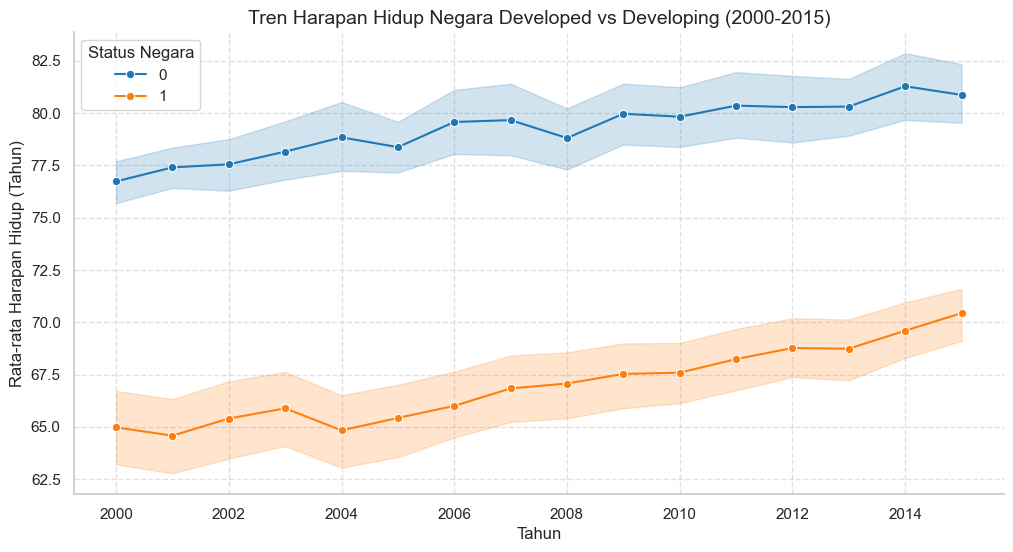

Kenaikan Harapan Hidup (2000 ke 2015):
Status
0    4.135897
1    5.461789
dtype: float64


In [ ]:
# Filter data tahun 2000-2015
df_2000_2015 = df_train[(df_train['Year'] >= 2000) & (df_train['Year'] <= 2015)]

# Visualisasi tren harapan hidup
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_2000_2015, x='Year', y='Life expectancy', hue='Status', marker='o', palette=['#1f77b4', '#ff7f0e'])

plt.title('Tren Harapan Hidup Negara Developed vs Developing (2000-2015)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Rata-rata Harapan Hidup (Tahun)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Status Negara')
plt.show()

# Menghitung increase harapan hidup dari tahun 2000 ke 2015
gap = df_2000_2015.groupby(['Year', 'Status'])['Life expectancy'].mean().unstack()
increase = gap.loc[2015] - gap.loc[2000]
print("Kenaikan Harapan Hidup (2000 ke 2015):")
print(increase)

##### Interpretasi
*   Dari grafik dapat dilihat bahwa terdapat gap yang konsisten antara negara Developed dan Developing dalam rata-rata harapan hidup selama 15 tahun. Rata-rata harapan hidup di negara Develop mencapai 75-80 tahun sementara hanya berkisar 60-70 tahun di negara Developing. Hal ini menunjukkan bahwa ada kesenjangan yang cukup besar antara harapan hidup di negara Develop dan Developing.
*    Meskipun harapan hidup secara global memiliki tren positif, dapat dilihat bahwa negara Developing memiliki kemajuan yang lebih dinamis. Grafik menunjukkan dengan jelas bahwa slope pada negara Developing lebih curam sehingga menandakan peningkatan harapan hidup yang signifikan. Sebaliknya, harapan hidup pada negara Developed terlihat lebih landai yang menandakan kenaikan stabil.
*    Jika diperhatikan secara menyeluruh, jarak kedua garis (antara Develop dan Developing) menyempit pada beberapa tahun terakhir. Dari sini dapat dilihat bahwa negara Developing sudah mulai mengejar angka harapan hidup dari negara Develop, meskipun masih memiliki selisih yang cukup tinggi.

#### Aydin

Apakah cakupan imunisasi (`Hepatitis B`, `Polio`, `Diphtheria`) mempengaruhi tingkat kematian bayi (`infant deaths`)?

Korelasi antara Imunisasi dan Kematian Bayi:
             infant deaths
Hepatitis B      -0.131593
Polio            -0.214091
Diphtheria       -0.256836


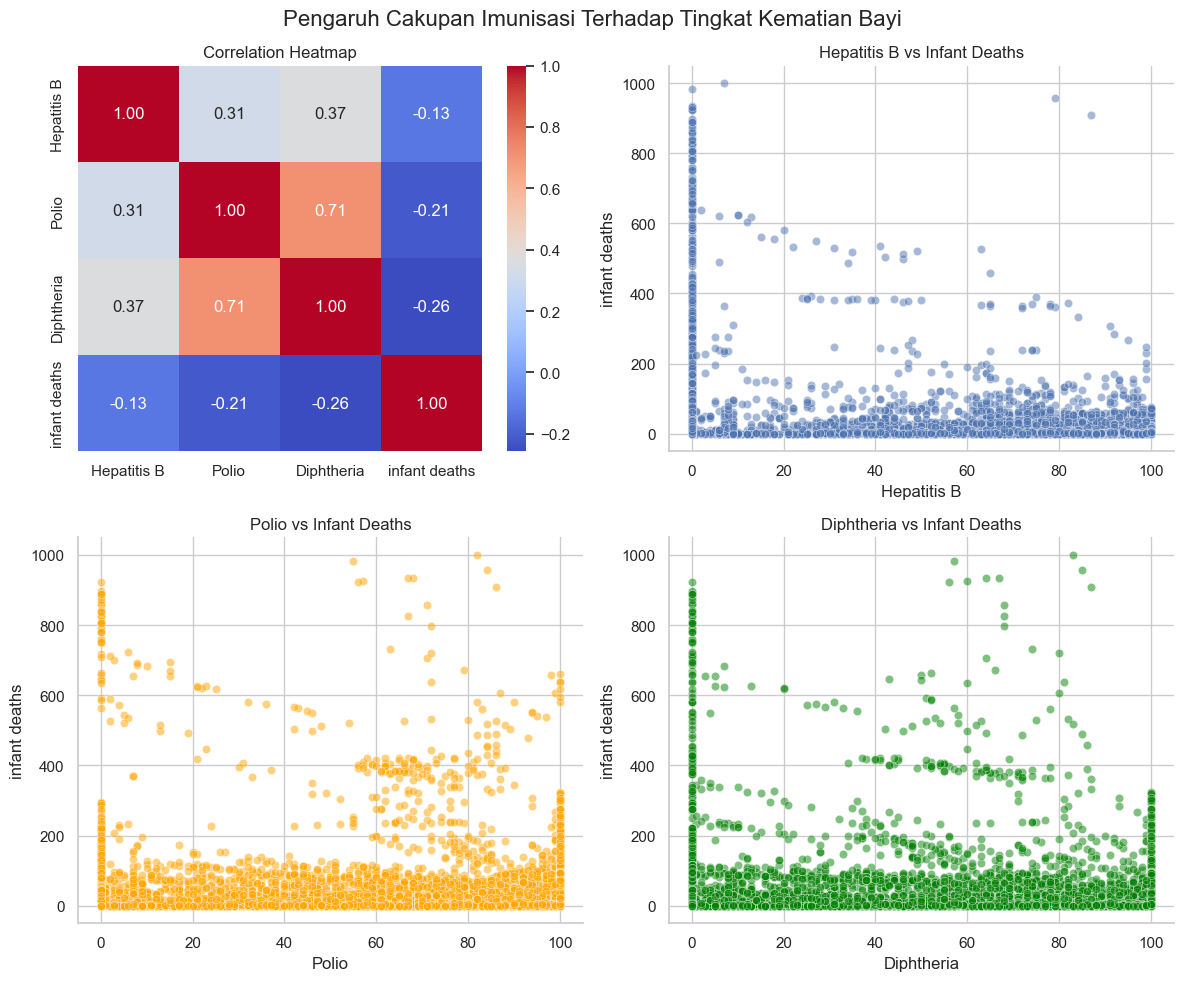

In [ ]:
# Pre-processing
kolom_imunisasi = ['Hepatitis B', 'Polio', 'Diphtheria', 'infant deaths']
df_imun = df_train[kolom_imunisasi].copy()

# Menangani Missing Values (Mengisi dengan Median)
for col in ['Hepatitis B', 'Polio', 'Diphtheria']:
    df_imun[col].fillna(df_imun[col].median())

# Menghitung Korelasi
korelasi = df_imun.corr()
print("Korelasi antara Imunisasi dan Kematian Bayi:")
print(korelasi[['infant deaths']].drop('infant deaths'))

# Membuat Visualisasi Heatmap dan Scatter Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Pengaruh Cakupan Imunisasi Terhadap Tingkat Kematian Bayi', fontsize=16)

# Heatmap
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap')

# Scatter Plot Hepatitis B
sns.scatterplot(data=df_imun, x='Hepatitis B', y='infant deaths', alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title('Hepatitis B vs Infant Deaths')

# Scatter Plot Polio
sns.scatterplot(data=df_imun, x='Polio', y='infant deaths', alpha=0.5, color='orange', ax=axes[1, 0])
axes[1, 0].set_title('Polio vs Infant Deaths')

# Scatter Plot Diphtheria
sns.scatterplot(data=df_imun, x='Diphtheria', y='infant deaths', alpha=0.5, color='green', ax=axes[1, 1])
axes[1, 1].set_title('Diphtheria vs Infant Deaths')

plt.tight_layout()
plt.show()

##### Interpretasi

- Terdapat korelasi negatif antara tingkat cakupan imunisasi dengan jumlah kematian bayi (infant deaths). Nilai korelasi berturut-turut adalah: Diphtheria (-0.26), Polio (-0.21), dan Hepatitis B (-0.13).

- Korelasi negatif ini menunjukkan bahwa semakin tinggi persentase cakupan imunisasi dasar, maka jumlah kematian bayi cenderung semakin menurun.

- Angka korelasi yang relatif kecil (mendekati 0) ini sangat wajar terjadi pada data riil kesehatan global. Kematian bayi adalah permasalahan kompleks yang tidak bisa diselesaikan hanya dengan imunisasi saja. Faktor lain seperti status gizi ibu dan anak dan sanitasi memegang peranan yang sangat besar sehingga mengurangi kekuatan korelasi imunisasi itu sendiri.

- Ditemukan korelasi positif yang sangat kuat (0.71) antara cakupan imunisasi Polio dan Diphtheria. Hal ini disebabkan oleh program imunisasi global di mana kedua vaksin tersebut rutin diberikan secara bersamaan pada jadwal usia yang sama. Sebaliknya, Hepatitis B memiliki korelasi yang lebih rendah terhadap keduanya karena merupakan program yang diadopsi lebih belakangan oleh negara berkembang dan memiliki tantangan logistik khusus, yaitu keharusan untuk diberikan dalam kurun waktu 24 jam pertama setelah bayi lahir (birth dose)

---

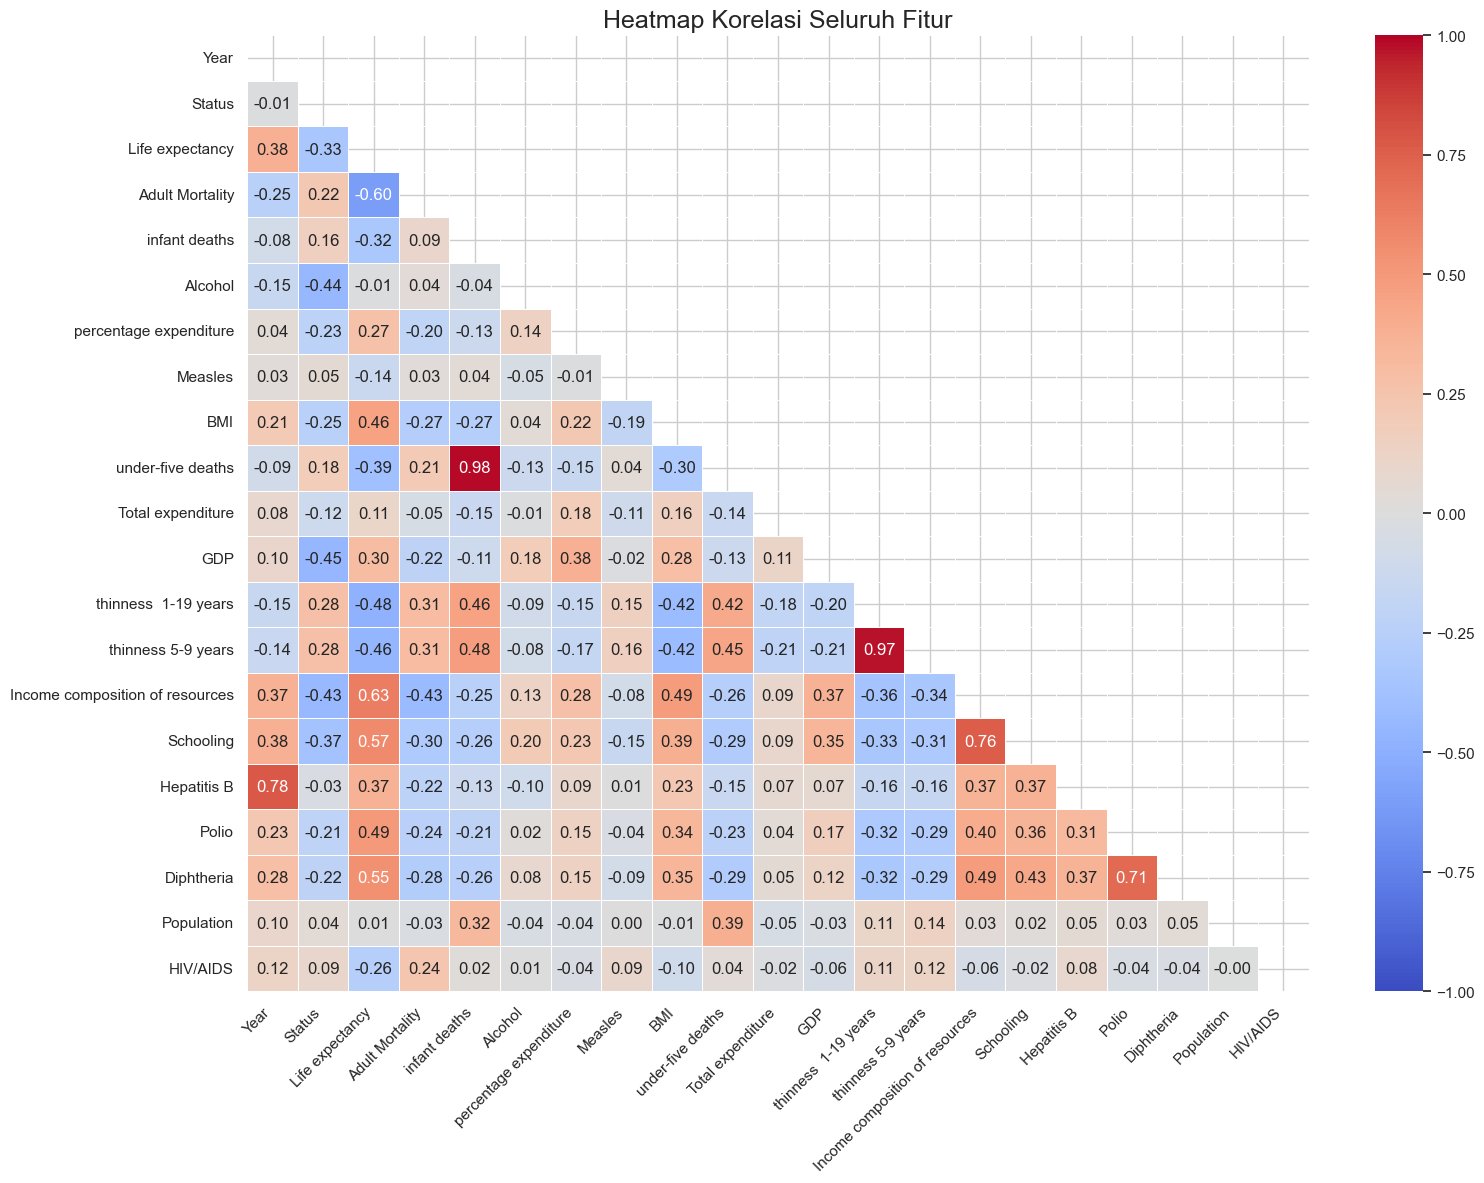

In [ ]:
numeric_df = df_train.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Seluruh Fitur', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
def clean(df):
    # 1. thinness 5-9 years dan thinness  1-19 years memiliki korelasi sangat tinggi
    df.drop(columns=['thinness 5-9 years'], inplace=True)

    # 2. under five deaths dan infant deaths memiliki korelasi sangat tinggi
    df.drop(columns=['infant deaths'], inplace=True)

    # 3. Polio dan Diphtheria memiliki korelasi tinggi
    df.drop(columns=['Diphtheria'], inplace=True)

    # 4. percentage expenditure banyak null value (>50%)
    df.drop(columns=['percentage expenditure'], inplace=True)

    # 5. Income composition of resources merupakan fitur turunan
    df.drop(columns=['Income composition of resources'], inplace=True)

    # 6. Year tidak relevan
    df.drop(columns=['Year'], inplace=True)


clean(df_train)
clean(df_test)

 Jumlah Missing Values  Jumlah Row  Persentase (%)
                     0        6089           60.47
                     1        3261           32.38
                     2         479            4.76
                     3         126            1.25
                     4          67            0.67
                     5          31            0.31
                     6          11            0.11
                     7           6            0.06


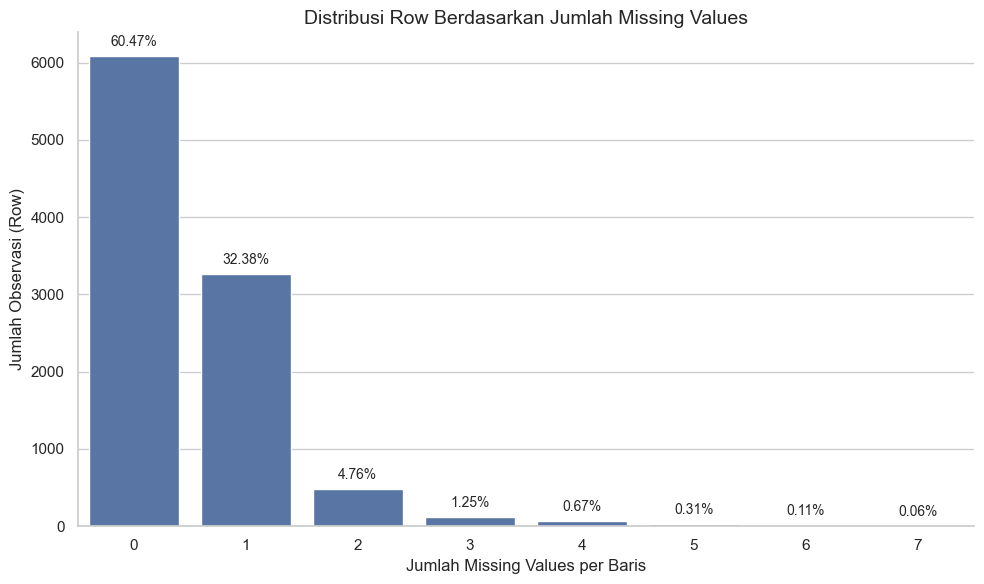

In [ ]:
missing_counts = df_train.isnull().sum(axis=1)

dist = missing_counts.value_counts().sort_index()
dist_pct = (missing_counts.value_counts(normalize=True).sort_index() * 100).round(2)

missing_summary_df = pd.DataFrame({
    'Jumlah Missing Values': dist.index,
    'Jumlah Row': dist.values,
    'Persentase (%)': dist_pct.values
})

print(missing_summary_df.to_string(index=False))

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=missing_summary_df, x='Jumlah Missing Values', y='Jumlah Row')

for p, pct in zip(ax.patches, missing_summary_df['Persentase (%)']):
    ax.annotate(f"{pct}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribusi Row Berdasarkan Jumlah Missing Values', fontsize=14)
plt.xlabel('Jumlah Missing Values per Baris', fontsize=12)
plt.ylabel('Jumlah Observasi (Row)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
df_clean = df_train[missing_counts < 4].copy()

print(f"Jumlah baris awal: {len(df_train)}")
print(f"Jumlah baris setelah dibersihkan: {len(df_clean)}")
print(f"Total baris yang dihapus (>= 4 missing values): {len(df_train) - len(df_clean)}")

df_train = df_clean.reset_index(drop=True)

Jumlah baris awal: 10070
Jumlah baris setelah dibersihkan: 9955
Total baris yang dihapus (>= 4 missing values): 115


In [ ]:
# Impute dengan KNNImputer

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

cols = df_train.columns
df_imputed = imputer.fit_transform(df_train)

# Kembalikan ke bentuk dataframe
df_train = pd.DataFrame(df_imputed, columns=cols)

display(df_train)

X = df_train.drop(columns=['Life expectancy', 'Status'])
y = df_train['Status']

,Status,Life expectancy,Adult Mortality,Alcohol,Measles,BMI,under-five deaths,Total expenditure,GDP,thinness 1-19 years,Schooling,Hepatitis B,Polio,Population,HIV/AIDS
0,0.0,75.958705,30.409030,16.891705,197.2,7.022069,10.0,20.000000,79835.055962,0.633306,12.774990,0.0,76.0,64121.00,0.100000
1,1.0,42.915277,101.499444,8.230195,273.6,5.000000,28.0,3.613611,10.000000,11.396052,9.982904,100.0,53.0,2364183.00,4.976989
2,1.0,49.322096,209.702245,0.010000,0.0,30.193667,108.0,6.405683,1766.947595,4.906007,7.317002,0.0,100.0,821554.00,0.100000
3,1.0,30.000000,452.548059,5.347899,42.2,10.879758,298.0,0.000000,1766.947595,11.346782,12.300000,0.0,83.0,738541.00,0.100000
4,1.0,61.800000,261.000000,1.340000,276.0,15.600000,243.0,6.860000,341.399920,11.000000,8.100000,62.0,69.0,877267.00,1.700000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9950,1.0,54.000000,496.000000,8.500000,81.0,44.300000,82.0,7.570000,5631.734850,1.600000,12.900000,83.0,79.0,4823384.48,28.100000
9951,0.0,61.091817,93.906388,15.523594,19.0,80.000000,6.0,0.000000,18180.412076,1.309101,14.667046,0.0,100.0,4860065.00,0.100000
9952,1.0,63.257414,14.720870,0.562890,197.2,5.000000,30.0,0.100080,10.000000,6.375319,5.548524,0.0,100.0,10777319.00,0.100000
9953,1.0,55.229174,296.233241,5.632786,219.8,14.602534,23.0,5.879722,1766.947595,0.100000,6.587215,0.0,15.0,1210398.00,0.194655


## Model Fitting

### Cathlin

In [ ]:
# LightGMB (Boosting)

# model
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

# split untuk simulasi
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

lgbm_model = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)

param_grid_lgbm = {
    'n_estimators': [100, 200, 300],       # berapa kali dia belajar dari kesalahan
    'max_depth': [5, 7, 10, -1],           # depths (-1 artinya tanpa batas)
    'learning_rate': [0.01, 0.05, 0.1],    # kecepatan belajar
    'num_leaves': [31, 50, 100],           # jumlah max. daun
    'colsample_bytree': [0.8, 1.0],        # acak 80% kolom biar gaa ngafal mati
    'min_child_samples': [10, 20]          # batas minimal data per kelompok
}

grid_search_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    cv=5,
    n_jobs=-1,
    scoring='f1'        # cari kombinasi yang F1-Score-nya tertinggi
)

# belajar pake data latihan
grid_search_lgbm.fit(X, y)

best_lgbm = grid_search_lgbm.best_estimator_
print(grid_search_lgbm.best_params_)

estimasi_f1_kaggle = grid_search_lgbm.best_score_
print(f"\nestimasi score kaggle: {estimasi_f1_kaggle:.4f}")

jawaban_latihan = best_lgbm.predict(X)
f1_latihan = f1_score(y, jawaban_latihan)
print(f"f1 score dari data latihan: {f1_latihan:.4f}")

jawaban_lgbm = best_lgbm.predict(df_test)

lembar_jawaban_lgbm = pd.DataFrame({
    'id': df_test.index,
    'Status': jawaban_lgbm
})

display(lembar_jawaban_lgbm)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}

estimasi score kaggle: 0.9978
f1 score dari data latihan: 1.0000


,id,Status
0,0,1.0
1,1,1.0
2,2,1.0
3,3,1.0
4,4,1.0
...,...,...
1254,1254,1.0
1255,1255,0.0
1256,1256,1.0
1257,1257,1.0


### Arya

In [ ]:
import imblearn
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
# Make the pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler()),
    ('oversampler', imblearn.over_sampling.BorderlineSMOTE(k_neighbors=3)),
    ('model', KNeighborsClassifier(n_neighbors=3, metric="manhattan", weights="distance"))
])

parameter_grid = {
    "imputer__strategy": ["median", "mean"],
    "model__n_neighbors": [3, 5, 7, 9],
    "model__metric": ["manhattan", "euclidean"],
    "model__weights": ["uniform", "distance"]
}

grid = GridSearchCV(
    pipeline,
    parameter_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'imputer__strategy': 'median', 'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}
Best score: 0.9845721953096153


In [ ]:
pipeline.fit(X, y)

# # Predict the result
res = pipeline.predict(df_test)
res_df = pd.DataFrame(res, columns=['Status'])
res_df.index.names = ['id']

display(res_df)

,Status
id,
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
1254,1.0
1255,0.0
1256,1.0


### Aulya

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

model_final = RandomForestClassifier(
    n_estimators=2000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Training model
model_final.fit(X, y)
train_preds = model_final.predict(X)
score_f1_train = f1_score(y, train_preds)

print(f"F1-Score pada data training: {score_f1_train:.4f}")

preds = model_final.predict(df_test)

preds_df = pd.DataFrame({
    'id': df_test.index,
    'Status': preds
})

display(preds_df)

F1-Score pada data training: 1.0000


,id,Status
0,0,1.0
1,1,1.0
2,2,1.0
3,3,1.0
4,4,1.0
...,...,...
1254,1254,1.0
1255,1255,0.0
1256,1256,1.0
1257,1257,1.0


### Aydin

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("Training the XGBoost model on the full dataset...")
xgb_model = xgb.XGBClassifier(
    n_estimators=300,             # Increased trees for final submission
    learning_rate=0.05,           # Slightly lower learning rate for better generalization
    max_depth=6,                  # Depth of trees
    subsample=0.8,                # Prevent overfitting by sampling 80% of data per tree
    colsample_bytree=0.8,         # Prevent overfitting by sampling 80% of features per tree
    random_state=42,
    eval_metric='logloss'         # Handled missing values (NaNs) automatically
)

xgb_model.fit(X, y)

print("Generating predictions for test.csv...")
test_predictions = xgb_model.predict(X)

dynamic_ids = np.arange(len(test_predictions))

submission_df = pd.DataFrame({
    'id': dynamic_ids,
    'Status': test_predictions
})

display(submission_df)

Training the XGBoost model on the full dataset...
Generating predictions for test.csv...


,id,Status
0,0,0
1,1,1
2,2,1
3,3,1
4,4,1
...,...,...
9950,9950,1
9951,9951,0
9952,9952,1
9953,9953,1
